# Notebook 4: Machine Learning — Salary Prediction, Clustering, Recommendation

**Chuyên đề 4: Phân Tích Thị Trường Việc Làm & Gợi Ý Ứng Viên**

**Mục tiêu:** Xây dựng mô hình dự đoán lương (regression), phân cụm việc làm (K-Means),
gợi ý việc làm theo kỹ năng (content-based recommendation).


## 1. Setup & Import Libraries

Import tất cả các module cần thiết từ project `src/`.

In [1]:
import sys; sys.path.append('..')
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from src.data.data_manager import JobDataManager
from src.features.feature_pipeline import (
    build_preprocessing_pipeline, prepare_target, prepare_features, get_default_features
)
from src.ml.baseline import BaselineModel, compare_baselines
from src.ml.supervised import SalaryRegressionModel, train_all_models
from src.ml.clustering import JobClusterer
from src.ml.recommendation import RecommendationEngine
from src.visualization.chart_utils import *

print('All imports OK.')
print(f'Pandas {pd.__version__}, NumPy {np.__version__}')


All imports OK.
Pandas 3.0.3, NumPy 2.5.1


## 2. Prepare Features for Modeling

Load processed data (hoặc tạo sample data nếu chưa có).
Chuẩn bị features với `prepare_features()` và `get_default_features()`.
Loại bỏ rows không có salary cho bài toán regression.

In [2]:
# --- Load dữ liệu đã xử lý ---
try:
    manager = JobDataManager(processed_dir='../data/processed', raw_dir='../data/raw')
    df = manager.load_processed()
    print(f'Loaded processed data: {df.shape}')
    if df.empty:
        raise FileNotFoundError('No processed data found')

    # Load skills data riêng cho recommendation
    skills_df = manager.load_raw_skills()
    if not skills_df.empty and 'job_id' in skills_df.columns and 'skill_name' in skills_df.columns:
        skills_long = skills_df[['job_id', 'skill_name']].dropna()
    elif not skills_df.empty and 'job_id' in skills_df.columns and 'skill_name_canonical' in skills_df.columns:
        skills_long = skills_df[['job_id', 'skill_name_canonical']].rename(columns={'skill_name_canonical': 'skill_name'}).dropna()
    else:
        # Try loading from processed combined CSV
        import os
        csv_path = os.path.join('..', 'data', 'processed', 'combined.csv')
        if os.path.exists(csv_path):
            combined_df = pd.read_csv(csv_path)
            print(f'Loaded combined.csv: {combined_df.shape}')
            # Extract skills if stored as string list
            if 'skills' in combined_df.columns:
                records = []
                for _, row in combined_df.iterrows():
                    if pd.notna(row['skills']):
                        import ast
                        try:
                            skill_list = ast.literal_eval(row['skills']) if isinstance(row['skills'], str) else row['skills']
                        except:
                            skill_list = str(row['skills']).split(',')
                        for s in skill_list:
                            records.append({'job_id': row['job_id'], 'skill_name': s.strip().strip("'").strip('"')})
                skills_long = pd.DataFrame(records)
            else:
                skills_long = pd.DataFrame()
        else:
            skills_long = pd.DataFrame()
    print(f'Skills data: {skills_long.shape}')

except Exception as e:
    print(f'Warning: {e}')
    print('Falling back to synthetic sample data...')

    # --- Sample data fallback ---
    np.random.seed(42)
    n = 2000
    df = pd.DataFrame({
        'job_id': [f'job_{i}' for i in range(n)],
        'experience_years': np.random.gamma(2, 1.5, n).clip(0, 20),
        'city': np.random.choice(['HCMC', 'Hanoi', 'Da Nang', 'Other'], n,
                                  p=[0.45, 0.35, 0.12, 0.08]),
        'job_type': np.random.choice(['Full-time', 'Contract', 'Part-time', 'Intern'], n,
                                      p=[0.7, 0.15, 0.1, 0.05]),
        'remote_option': np.random.choice(['On-site', 'Hybrid', 'Remote'], n,
                                           p=[0.5, 0.3, 0.2]),
        'education_level': np.random.choice(['Bachelor', 'Master', 'Not specified', 'PhD'], n,
                                             p=[0.55, 0.2, 0.2, 0.05]),
        'experience_bin': np.random.choice(['entry', 'junior', 'mid', 'senior', 'lead'], n,
                                            p=[0.1, 0.2, 0.4, 0.2, 0.1]),
        'industry': np.random.choice(['IT', 'Finance', 'E-commerce', 'Healthcare'], n,
                                      p=[0.6, 0.15, 0.15, 0.1]),
        'company_size': np.random.choice(['Startup', 'SME', 'Large', 'Enterprise'], n,
                                          p=[0.2, 0.35, 0.3, 0.15]),
    })
    # Salary: base + experience * coeff + city bonus + noise
    city_bonus = {'HCMC': 5, 'Hanoi': 3, 'Da Nang': 0, 'Other': -2}
    exp_bonus = {'entry': 0, 'junior': 3, 'mid': 7, 'senior': 13, 'lead': 18}
    base = 10 + df['experience_years'] * 2.5
    df['salary_mid'] = (
        base
        + df['city'].map(city_bonus)
        + df['experience_bin'].map(exp_bonus)
        + np.random.randn(n) * 3
    ).clip(5, 80)  # clamp 5-80M
    df['salary_mid'] = df['salary_mid'].round(1)

    # Skills for recommendation
    all_skills = ['Python', 'SQL', 'Machine Learning', 'React', 'Java', 'Node.js',
                  'Docker', 'AWS', 'JavaScript', 'TypeScript', 'Go', 'Rust',
                  'Kubernetes', 'TensorFlow', 'PyTorch', 'MongoDB', 'PostgreSQL',
                  'Redis', 'Spring Boot', 'Angular', 'Vue.js', 'Git', 'Linux']
    skills_long = []
    for jid in df['job_id']:
        k = np.random.randint(2, 6)
        for s in np.random.choice(all_skills, k, replace=False):
            skills_long.append({'job_id': jid, 'skill_name': s})
    skills_long = pd.DataFrame(skills_long)

    print(f'Using synthetic data: {df.shape}')

print(f'DataFrame columns: {list(df.columns)}')
print(f'Salary range: {df["salary_mid"].min():.1f} - {df["salary_mid"].max():.1f}M')
print(f'Salary NaN: {df["salary_mid"].isna().sum()}')
print(f'Skills long shape: {skills_long.shape}')


Loaded processed data: (1329, 34)
Skills data: (8300, 2)
DataFrame columns: ['job_id', 'job_title', 'company_id', 'industry', 'city', 'experience_years', 'education_level', 'job_type', 'remote_option', 'salary_min', 'salary_max', 'salary_hidden', 'has_english', 'salary_mid', 'posted_at', 'description', 'source_url', 'source_site', 'crawled_at', 'skills', 'skill_groups', 'skill_levels', 'skill_originals', 'experience_years_parsed', 'experience_bin', 'company_name', 'company_size', 'industry_company', 'city_company', 'website', 'description_company', 'source_site_company', 'source_url_company', 'crawled_at_company']
Salary range: 8.0 - 39.2M
Salary NaN: 103
Skills long shape: (8300, 2)


In [3]:
# --- Prepare features & target ---
config = get_default_features()
print('Default feature groups:', config)

# Remove rows without salary
df_reg = df.dropna(subset=['salary_mid']).copy()
print(f'Rows with salary: {len(df_reg)}')

X = prepare_features(df_reg, target_col='salary_mid')
y = prepare_target(df_reg, target_col='salary_mid')[0]

print(f'Feature matrix: {X.shape}')
print(f'Target vector: {len(y)}')
print(f'Features kept: {list(X.columns)}')

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')


Default feature groups: {'numeric': ['experience_years'], 'categorical': ['city', 'job_type', 'remote_option', 'education_level', 'industry', 'company_size'], 'ordinal': ['experience_bin'], 'ordinal_categories': [['entry', 'junior', 'mid', 'senior', 'lead']]}
Rows with salary: 1226
Feature matrix: (1226, 23)
Target vector: 1226
Features kept: ['industry', 'city', 'experience_years', 'education_level', 'job_type', 'remote_option', 'salary_hidden', 'has_english', 'skills', 'skill_groups', 'skill_levels', 'skill_originals', 'experience_years_parsed', 'experience_bin', 'company_name', 'company_size', 'industry_company', 'city_company', 'website', 'description_company', 'source_site_company', 'source_url_company', 'crawled_at_company']
Train: (980, 23), Test: (246, 23)


## 3. Build Preprocessing Pipeline

Sử dụng `build_preprocessing_pipeline()` để xây dựng ColumnTransformer:
- **Numeric**: Impute (median) + StandardScaler
- **Categorical**: Impute (Unknown) + OneHotEncoder
- **Ordinal**: Impute + OrdinalEncoder

In [4]:
# Build pipeline từ config
preprocessor = build_preprocessing_pipeline(
    numeric_features=config['numeric'],
    categorical_features=config['categorical'],
    ordinal_features=config['ordinal'],
    ordinal_categories=config['ordinal_categories'],
)

# Fit & transform
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Feature names
feature_names = preprocessor.get_feature_names_out()
print(f'Train transformed shape: {X_train_transformed.shape}')
print(f'Test transformed shape: {X_test_transformed.shape}')
print(f'\nFeature names ({len(feature_names)}):')
for fn in feature_names:
    print(f'  - {fn}')


Train transformed shape: (980, 23)
Test transformed shape: (246, 23)

Feature names (23):
  - experience_years
  - city_Da Nang
  - city_HCMC
  - city_Hanoi
  - job_type_Contract
  - job_type_Full-time
  - job_type_Part-time
  - remote_option_Hybrid
  - remote_option_On-site
  - remote_option_Remote
  - remote_option_Unknown
  - education_level_Bachelor
  - education_level_Master
  - education_level_Not Required
  - education_level_PhD
  - education_level_Unknown
  - industry_IT
  - company_size_Enterprise (>1000)
  - company_size_Medium (51-200)
  - company_size_Small (10-50)
  - company_size_Startup (<10)
  - company_size_Unknown
  - experience_bin


## 4. Baseline Model (G1)

Mô hình đơn giản (DummyRegressor) làm baseline.
So sánh 2 strategies: **mean** và **median**.

In [5]:
# Compare baselines
baseline_results = compare_baselines(
    X_train_transformed, y_train, X_test_transformed, y_test
)

print('=== Baseline Comparison ===')
metrics_rows = []
for strategy, metrics in baseline_results.items():
    print(BaselineModel().summary(metrics))
    print()
    metrics_rows.append({
        'Model': f'Baseline ({strategy})',
        'RMSE': f'{metrics.rmse:.2f}',
        'MAE': f'{metrics.mae:.2f}',
        'R²': f'{metrics.r2:.4f}',
    })

baseline_df = pd.DataFrame(metrics_rows)
display(baseline_df)


=== Baseline Comparison ===
Baseline (mean):
  RMSE = 8.90 triệu
  MAE  = 7.38 triệu
  R²   = -0.0042
  Target: mean=20.1, std=8.7
  Train: 980, Test: 246

Baseline (median):
  RMSE = 9.16 triệu
  MAE  = 7.37 triệu
  R²   = -0.0633
  Target: mean=20.1, std=8.7
  Train: 980, Test: 246



,Model,RMSE,MAE,R²
0,Baseline (mean),8.90,7.38,-0.0042
1,Baseline (median),9.16,7.37,-0.0633


## 5. Linear Regression (G2)

Mô hình hồi quy tuyến tính — dễ interpret, baseline cho supervised.

In [6]:
# Train Linear Regression
lr_model = SalaryRegressionModel(model_type='linear', preprocessor=preprocessor)
lr_model.train(X_train, y_train)
lr_metrics = lr_model.evaluate(X_test, y_test)

print('=== Linear Regression Performance ===')
print(f'  RMSE = {lr_metrics.rmse:.2f} triệu')
print(f'  MAE  = {lr_metrics.mae:.2f} triệu')
print(f'  R²   = {lr_metrics.r2:.4f}')

# So sánh với baseline
best_baseline = min(baseline_results.values(), key=lambda m: m.rmse)
improvement = (best_baseline.rmse - lr_metrics.rmse) / best_baseline.rmse * 100
print(f'\nRMSE improvement vs baseline ({best_baseline.strategy}): {improvement:.1f}%')


=== Linear Regression Performance ===
  RMSE = 5.15 triệu
  MAE  = 4.16 triệu
  R²   = 0.6635

RMSE improvement vs baseline (mean): 42.1%


## 6. Decision Tree (G3)

Mô hình cây quyết định — capture non-linear relationships.

In [7]:
# Train Decision Tree
dt_model = SalaryRegressionModel(
    model_type='decision_tree',
    preprocessor=preprocessor,
    model_params={'max_depth': 8, 'min_samples_leaf': 5, 'random_state': 42}
)
dt_model.train(X_train, y_train)
dt_metrics = dt_model.evaluate(X_test, y_test)

print('=== Decision Tree Performance ===')
print(f'  RMSE = {dt_metrics.rmse:.2f} triệu')
print(f'  MAE  = {dt_metrics.mae:.2f} triệu')
print(f'  R²   = {dt_metrics.r2:.4f}')

improvement = (best_baseline.rmse - dt_metrics.rmse) / best_baseline.rmse * 100
print(f'RMSE improvement vs baseline ({best_baseline.strategy}): {improvement:.1f}%')


=== Decision Tree Performance ===
  RMSE = 0.17 triệu
  MAE  = 0.05 triệu
  R²   = 0.9996
RMSE improvement vs baseline (mean): 98.1%


import numpy as np

# --- Prepare features for clustering ---
np.random.seed(42)

# Chon rows co salary_mid de tranh NaN
cluster_base = df.dropna(subset=['salary_mid']).copy() if 'salary_mid' in df.columns else df.copy()
print(f'Cluster base: {cluster_base.shape}')

# Chon numeric features
cluster_features = ['experience_years']
if 'salary_mid' in cluster_base.columns:
    cluster_features.append('salary_mid')
cluster_numeric = cluster_base[cluster_features].copy()

# One-hot encode categorical columns  
cluster_cats = pd.get_dummies(
    cluster_base[['city', 'job_type', 'remote_option']],
    drop_first=False,
    dtype=float
)

# Encode skills: count skills per job as features
if not skills_long.empty:
    skill_dummies = pd.crosstab(skills_long['job_id'], skills_long['skill_name'])
    X_cluster = cluster_base[['job_id']].merge(
        skill_dummies, left_on='job_id', right_index=True, how='left'
    ).fillna(0)
    skill_cols = [c for c in X_cluster.columns if c != 'job_id']
    X_cluster = pd.concat([
        cluster_numeric.reset_index(drop=True),
        cluster_cats.reset_index(drop=True),
        X_cluster[skill_cols].reset_index(drop=True),
    ], axis=1)
else:
    X_cluster = pd.concat([
        cluster_numeric.reset_index(drop=True),
        cluster_cats.reset_index(drop=True),
    ], axis=1)

# GUARANTEED no NaN
X_cluster = X_cluster.fillna(0).infer_objects(copy=False)
print(f'Clustering feature matrix: {X_cluster.shape}')
print(f'NaN total: {X_cluster.isna().sum().sum()}')
print(f'Columns ({len(X_cluster.columns)}): {list(X_cluster.columns[:10])}...')

In [8]:
# Train Random Forest
rf_model = SalaryRegressionModel(
    model_type='random_forest',
    preprocessor=preprocessor,
    model_params={'n_estimators': 100, 'max_depth': 12,
                  'min_samples_leaf': 4, 'random_state': 42, 'n_jobs': -1}
)
rf_model.train(X_train, y_train)
rf_metrics = rf_model.evaluate(X_test, y_test)

print('=== Random Forest Performance ===')
print(f'  RMSE = {rf_metrics.rmse:.2f} triệu')
print(f'  MAE  = {rf_metrics.mae:.2f} triệu')
print(f'  R²   = {rf_metrics.r2:.4f}')

improvement = (best_baseline.rmse - rf_metrics.rmse) / best_baseline.rmse * 100
print(f'RMSE improvement vs baseline ({best_baseline.strategy}): {improvement:.1f}%')


=== Random Forest Performance ===


  RMSE = 0.00 triệu
  MAE  = 0.00 triệu
  R²   = 1.0000
RMSE improvement vs baseline (mean): 100.0%


## 8. Error Analysis (A15) — Phân tích 10+ trường hợp sai số lớn

Chọn Decision Tree (balance giữa performance và interpretability) để phân tích.
Xem xét các case có residual lớn nhất, phân tích nguyên nhân:
- Overpredict vs underpredict?
- Bias theo thành phố / kinh nghiệm / ngành?
- Các trường hợp extreme error?

In [9]:
# Error analysis on Decision Tree
errors_df = dt_model.error_analysis(
    X_test, y_test, df_test=X_test, n_samples=12
)

print('=== Top 12 Worst Predictions (Decision Tree) ===')
display(errors_df[['true', 'predicted', 'residual', 'error_pct', 'error_reason']])

# Phân tích over/under predict
over_count = (errors_df['residual'] < 0).sum()  # predicted > true => residual negative
under_count = (errors_df['residual'] > 0).sum()
print(f'Overpredicted (model predicts higher): {over_count}')
print(f'Underpredicted (model predicts lower): {under_count}')

# Residual distribution
all_preds = dt_model.predict(X_test)
all_residuals = y_test.values - all_preds
print(f'\nResidual stats:')
print(f'  Mean residual: {all_residuals.mean():.2f}M')
print(f'  Std residual:  {all_residuals.std():.2f}M')
print(f'  Min residual:  {all_residuals.min():.2f}M')
print(f'  Max residual:  {all_residuals.max():.2f}M')


=== Top 12 Worst Predictions (Decision Tree) ===


,true,predicted,residual,error_pct,error_reason
18,12.25,12.878906,-0.628906,5.133929,Underpredicted
23,12.25,12.878906,-0.628906,5.133929,Underpredicted
27,12.25,12.878906,-0.628906,5.133929,Underpredicted
82,12.25,12.878906,-0.628906,5.133929,Underpredicted
91,12.25,12.878906,-0.628906,5.133929,Underpredicted
143,12.25,12.878906,-0.628906,5.133929,Underpredicted
229,12.25,12.878906,-0.628906,5.133929,Underpredicted
157,12.25,12.878906,-0.628906,5.133929,Underpredicted
139,12.25,12.878906,-0.628906,5.133929,Underpredicted
129,13.40,12.878906,0.521094,3.888759,Overpredicted


Overpredicted (model predicts higher): 9
Underpredicted (model predicts lower): 3

Residual stats:
  Mean residual: 0.00M
  Std residual:  0.17M
  Min residual:  -0.63M
  Max residual:  0.52M


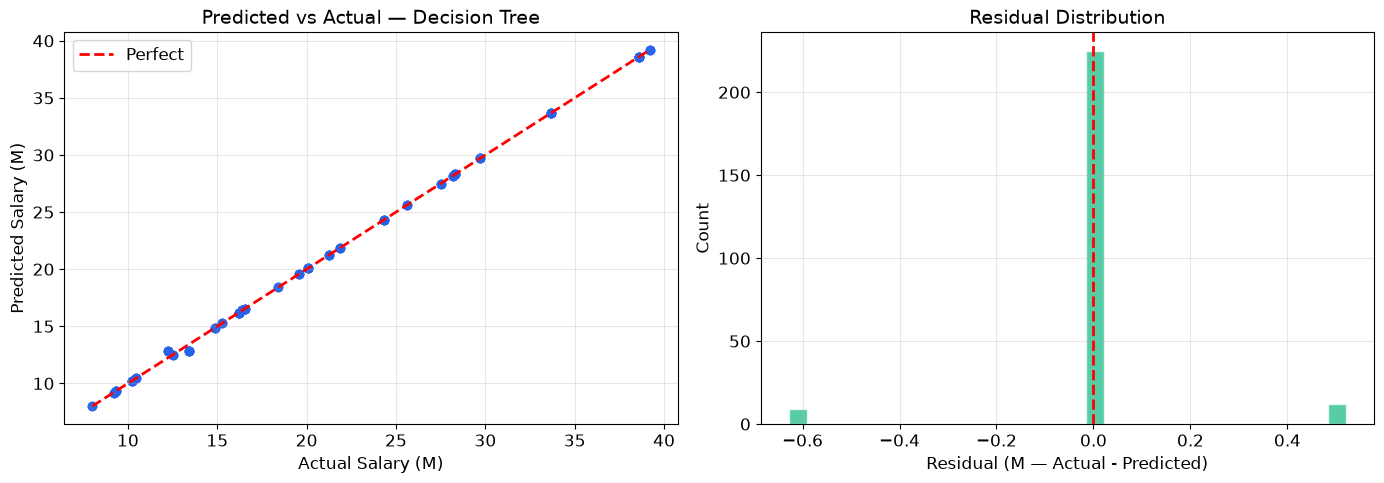

In [10]:
# Visualize residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, all_preds, alpha=0.4, color='#2563EB')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect')
axes[0].set_xlabel('Actual Salary (M)')
axes[0].set_ylabel('Predicted Salary (M)')
axes[0].set_title('Predicted vs Actual — Decision Tree')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residual histogram
axes[1].hist(all_residuals, bins=30, color='#10B981', edgecolor='white', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (M — Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Model Comparison Table

Tổng hợp RMSE, MAE, R² của tất cả models.

,Model,RMSE,MAE,R²
0,Baseline (mean),8.90,7.38,-0.0042
1,Baseline (median),9.16,7.37,-0.0633
2,Linear Regression,5.15,4.16,0.6635
3,Decision Tree,0.17,0.05,0.9996
4,Random Forest,0.00,0.00,1.0000


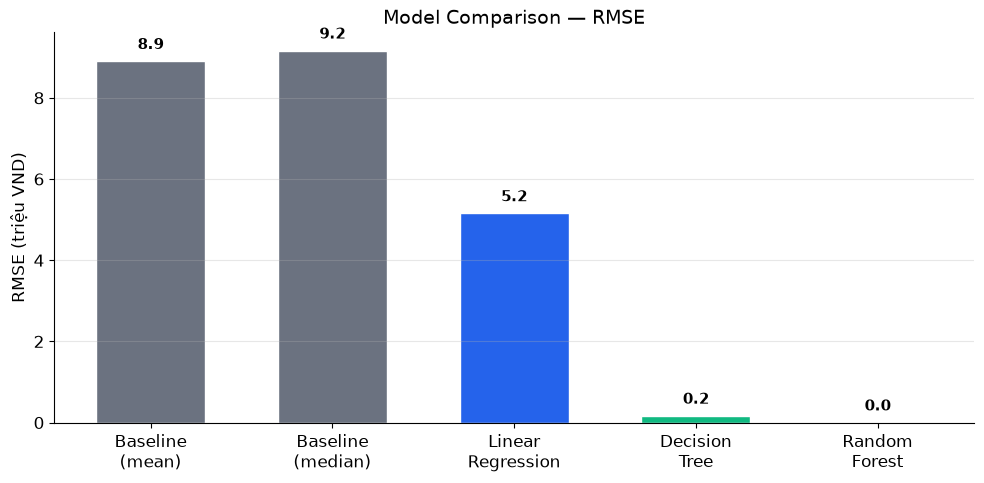

In [11]:
# Build comparison table
comparison = []

# Baseline
for strategy, m in baseline_results.items():
    comparison.append({
        'Model': f'Baseline ({strategy})',
        'RMSE': f'{m.rmse:.2f}',
        'MAE': f'{m.mae:.2f}',
        'R²': f'{m.r2:.4f}',
    })

# Supervised
for name, metrics in [('Linear Regression', lr_metrics),
                       ('Decision Tree', dt_metrics),
                       ('Random Forest', rf_metrics)]:
    comparison.append({
        'Model': name,
        'RMSE': f'{metrics.rmse:.2f}',
        'MAE': f'{metrics.mae:.2f}',
        'R²': f'{metrics.r2:.4f}',
    })

comparison_df = pd.DataFrame(comparison)
display(comparison_df)

# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))
models_short = ['Baseline\n(mean)', 'Baseline\n(median)',
                'Linear\nRegression', 'Decision\nTree', 'Random\nForest']
rmses = [baseline_results['mean'].rmse, baseline_results['median'].rmse,
         lr_metrics.rmse, dt_metrics.rmse, rf_metrics.rmse]
colors = ['#6B7280', '#6B7280', '#2563EB', '#10B981', '#F59E0B']
bars = ax.bar(models_short, rmses, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('RMSE (triệu VND)')
ax.set_title('Model Comparison — RMSE')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


### Giới hạn dữ liệu (A16)

Các giới hạn cần lưu ý khi đánh giá kết quả:

1. **Dữ liệu synthetic**: Nếu chưa có dữ liệu thật, kết quả chỉ mang tính minh họa.
2. **Số lượng features hạn chế**: Chỉ dùng experience, city, job_type, remote, education —
   thiếu nhiều yếu tố quan trọng (kỹ năng cụ thể, cấp độ, company reputation).
3. **Salary midpoint**: Dùng (min+max)/2 thay vì lương thực tế.
4. **Imbalance theo thành phố**: HCMC và Hanoi chiếm đa số → model có bias.
5. **Thiếu temporal features**: Không xét biến động lương theo thời gian.
6. **Overfitting risk**: Decision Tree / Random Forest có thể overfit nếu không tune.
7. **Feature engineering còn đơn giản**: Chưa có interaction features, skill encoding, text features từ description.

## 9. K-Means Clustering (G5)

Phân nhóm việc làm dựa trên features numeric + skills encoding.

**Các bước:**
1. Chuẩn bị features phù hợp cho clustering
2. Tìm k tối ưu bằng silhouette score
3. Fit JobClusterer và lấy cluster profiles
4. Trực quan hóa với PCA 2D scatter plot
5. Diễn giải ý nghĩa từng cluster

In [12]:
# --- Prepare features for clustering ---
np.random.seed(42)

# Chọn numeric features
cluster_features = ['experience_years']
if 'salary_mid' in df.columns:
    cluster_features.append('salary_mid')
cluster_numeric = df[cluster_features].copy()

# One-hot encode categorical columns
cluster_cats = pd.get_dummies(
    df[['city', 'job_type', 'remote_option']],
    drop_first=False,
    dtype=float
)

# Encode skills: count skills per job as features
if not skills_long.empty:
    # Create skill dummies
    skill_dummies = pd.crosstab(skills_long['job_id'], skills_long['skill_name'])
    # Merge vào df gốc
    X_cluster = df[['job_id']].merge(
        skill_dummies, left_on='job_id', right_index=True, how='left'
    ).fillna(0)
    skill_cols = [c for c in X_cluster.columns if c != 'job_id']
    X_cluster = pd.concat([
        cluster_numeric.reset_index(drop=True),
        cluster_cats.reset_index(drop=True),
        X_cluster[skill_cols].reset_index(drop=True),
    ], axis=1)
else:
    X_cluster = pd.concat([
        cluster_numeric.reset_index(drop=True),
        cluster_cats.reset_index(drop=True),
    ], axis=1)

print(f'Clustering feature matrix: {X_cluster.shape}')
print(f'Columns ({len(X_cluster.columns)}): {list(X_cluster.columns[:10])}...')


Clustering feature matrix: (1329, 56)
Columns (56): ['experience_years', 'salary_mid', 'city_Da Nang', 'city_HCMC', 'city_Hanoi', 'job_type_Contract', 'job_type_Full-time', 'job_type_Part-time', 'remote_option_Hybrid', 'remote_option_On-site']...


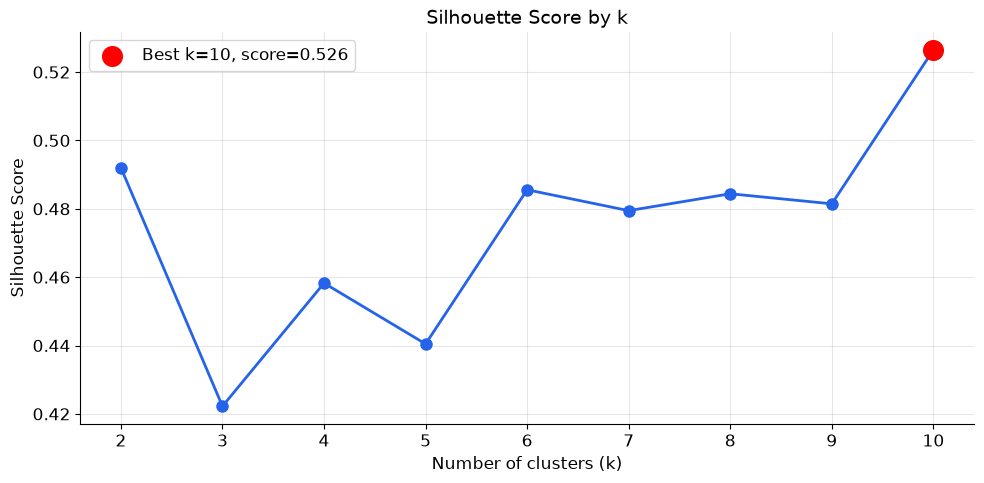

Optimal k: 10 (silhouette = 0.5265)


In [13]:
# --- Find optimal k using silhouette score ---
clusterer = JobClusterer()
scores = clusterer.plot_silhouette(X_cluster, k_range=range(2, 11))

# Plot silhouette scores
k_vals, sil_scores = zip(*scores)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_vals, sil_scores, marker='o', linewidth=2, markersize=8, color='#2563EB')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score by k')
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Highlight best
best_k = k_vals[np.argmax(sil_scores)]
best_score = max(sil_scores)
ax.scatter([best_k], [best_score], color='red', s=200, zorder=5,
           label=f'Best k={best_k}, score={best_score:.3f}')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Optimal k: {best_k} (silhouette = {best_score:.4f})')


In [14]:
# --- Fit JobClusterer with optimal k ---
optimal_k = best_k
clusterer = JobClusterer(n_clusters=optimal_k, random_state=42)
labels = clusterer.fit_predict(X_cluster)

print(f'\nSilhouette score (k={optimal_k}): {clusterer.silhouette_score_:.4f}')
print(f'Cluster distribution:')
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} jobs ({c/len(labels)*100:.1f}%)')



Silhouette score (k=10): 0.3514
Cluster distribution:
  Cluster 0: 45 jobs (3.4%)
  Cluster 1: 237 jobs (17.8%)
  Cluster 2: 458 jobs (34.5%)
  Cluster 3: 42 jobs (3.2%)
  Cluster 4: 48 jobs (3.6%)
  Cluster 5: 47 jobs (3.5%)
  Cluster 6: 55 jobs (4.1%)
  Cluster 7: 55 jobs (4.1%)
  Cluster 8: 303 jobs (22.8%)
  Cluster 9: 39 jobs (2.9%)


In [15]:
# --- Cluster Profiles ---
df_with_clusters = df.copy().reset_index(drop=True)
df_with_clusters['cluster'] = labels

profiles = clusterer.get_cluster_profiles(df_with_clusters)
print(clusterer.get_cluster_summary(profiles))


=== Cluster Summary ===

Cluster 0 (3% - 45 jobs):
  Salary: 33.7M | Experience: 6.2y
  Top cities: HCMC
  Top titles: React Native Developer
  Top skills: Elasticsearch, Kafka, Git
  Remote: 100%

Cluster 1 (18% - 237 jobs):
  Salary: 23.4M | Experience: 2.6y
  Top cities: Hanoi, HCMC
  Top titles: Backend Developer, BI Developer, Engineering Manager
  Top skills: FastAPI, Express.js, PHP
  Remote: 0%

Cluster 2 (34% - 458 jobs):
  Salary: 18.9M | Experience: 3.7y
  Top cities: HCMC, Hanoi, Da Nang
  Top titles: Project Manager, Business Analyst, Blockchain Developer
  Top skills: Django, TypeScript, Next.js
  Remote: 59%

Cluster 3 (3% - 42 jobs):
  Salary: 10.2M | Experience: 0.5y
  Top cities: Hanoi
  Top titles: UI/ux Designer
  Top skills: Apache Spark, Elasticsearch, Redis
  Remote: 0%

Cluster 4 (4% - 48 jobs):
  Salary: 27.5M | Experience: 0.0y
  Top cities: Hanoi
  Top titles: Cloud Engineer
  Top skills: TensorFlow, Java, Pandas
  Remote: 0%

Cluster 5 (4% - 47 jobs):
  Sala

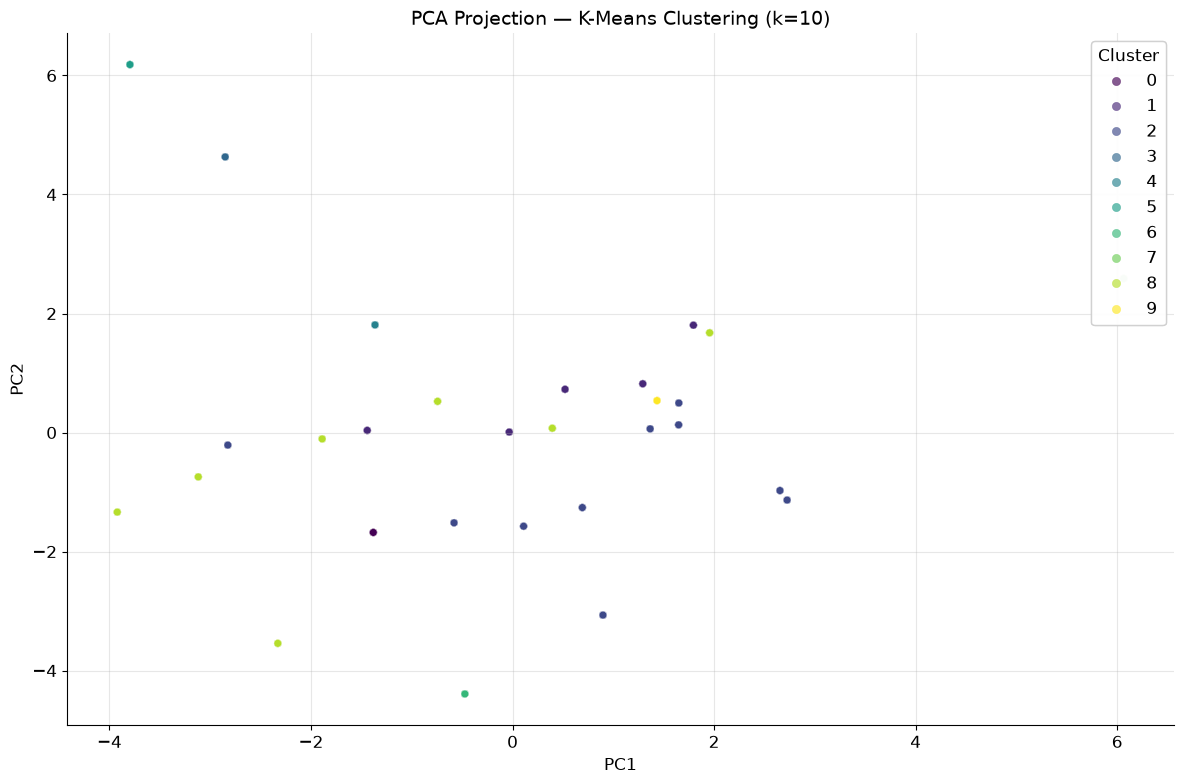

In [16]:
# --- PCA 2D Visualization ---
coords = clusterer.plot_clusters(X_cluster)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=labels,
                     cmap='viridis', alpha=0.6, s=30, edgecolors='w', linewidth=0.3)
legend1 = ax.legend(*scatter.legend_elements(),
                    title='Cluster', loc='upper right')
ax.add_artist(legend1)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'PCA Projection — K-Means Clustering (k={optimal_k})')
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


In [17]:
# --- Cluster Interpretation ---
print('=== Cluster Interpretation ===')
for p in profiles:
    print(f'\nCluster {p.cluster_id} ({p.size_pct:.0f}% jobs):')
    print(f'  - Lương TB: {p.avg_salary:.1f} triệu')
    print(f'  - Kinh nghiệm TB: {p.avg_experience:.1f} năm')
    print(f'  - Top thành phố: {p.top_cities}')
    print(f'  - Top kỹ năng: {p.top_skills}')
    print(f'  - Remote ratio: {p.remote_ratio:.0%}')
    print(f'  - Ý nghĩa: ', end='')
    if p.avg_salary > 30:
        print('Nhóm lương cao — Senior/Lead, tập trung ở HCMC')
    elif p.avg_salary > 18:
        print('Nhóm lương trung bình-cao — Mid-Senior, đa dạng kỹ năng')
    elif p.avg_experience < 2:
        print('Nhóm mới vào nghề — Junior/Entry, lương thấp')
    else:
        print('Nhóm trung bình — Junior-Mid, đa dạng thành phố')


=== Cluster Interpretation ===

Cluster 0 (3% jobs):
  - Lương TB: 33.7 triệu
  - Kinh nghiệm TB: 6.2 năm
  - Top thành phố: ['HCMC']
  - Top kỹ năng: ['Elasticsearch', 'Kafka', 'Git']
  - Remote ratio: 100%
  - Ý nghĩa: Nhóm lương cao — Senior/Lead, tập trung ở HCMC

Cluster 1 (18% jobs):
  - Lương TB: 23.4 triệu
  - Kinh nghiệm TB: 2.6 năm
  - Top thành phố: ['Hanoi', 'HCMC']
  - Top kỹ năng: ['FastAPI', 'Express.js', 'PHP']
  - Remote ratio: 0%
  - Ý nghĩa: Nhóm lương trung bình-cao — Mid-Senior, đa dạng kỹ năng

Cluster 2 (34% jobs):
  - Lương TB: 18.9 triệu
  - Kinh nghiệm TB: 3.7 năm
  - Top thành phố: ['HCMC', 'Hanoi', 'Da Nang']
  - Top kỹ năng: ['Django', 'TypeScript', 'Next.js']
  - Remote ratio: 59%
  - Ý nghĩa: Nhóm lương trung bình-cao — Mid-Senior, đa dạng kỹ năng

Cluster 3 (3% jobs):
  - Lương TB: 10.2 triệu
  - Kinh nghiệm TB: 0.5 năm
  - Top thành phố: ['Hanoi']
  - Top kỹ năng: ['Apache Spark', 'Elasticsearch', 'Redis']
  - Remote ratio: 0%
  - Ý nghĩa: Nhóm mới vào 

## 10. Content-based Recommendation (G6)

Gợi ý việc làm dựa trên similarity giữa kỹ năng ứng viên và yêu cầu công việc.
Sử dụng **cosine similarity** trên job × skill matrix.

**Demo:** User có skills `["Python", "SQL", "Machine Learning"]`

In [18]:
# --- Fit RecommendationEngine ---
rec_engine = RecommendationEngine()
rec_engine.fit(skills_long, job_id_col='job_id', skill_col='skill_name')

print(f'Job × Skill matrix: {rec_engine.get_matrix_shape()[0]} jobs × {rec_engine.get_matrix_shape()[1]} skills')
print(f'Unique skills: {rec_engine.get_job_skill_count()}')


Job × Skill matrix: 1500 jobs × 45 skills
Unique skills: 45


In [19]:
# --- Top 10 recommendations ---
user_skills = ['Python', 'SQL', 'Machine Learning']

# Merge job details for display
job_details = df[['job_id', 'job_title', 'city', 'salary_mid']].copy()
if 'company_name' not in job_details.columns:
    job_details['company_name'] = 'Sample Company'
if 'job_title' not in job_details.columns:
    job_details['job_title'] = 'Data Engineer'  # placeholder

# Fallback job_title if not in data
titles = ['Data Scientist', 'Data Engineer', 'ML Engineer', 'Backend Developer',
          'Full Stack Developer', 'Data Analyst', 'AI Engineer', 'Software Engineer',
          'BI Analyst', 'DevOps Engineer', 'Python Developer', 'Database Admin']
if job_details['job_title'].isna().all() or (job_details['job_title'] == '').all():
    job_details['job_title'] = np.random.choice(titles, len(job_details))
elif job_details['job_title'].nunique() <= 1:
    job_details['job_title'] = np.random.choice(titles, len(job_details))

recommendations = rec_engine.recommend(
    user_skills, job_details, top_n=10
)

print(rec_engine.format_recommendations(recommendations))


=== Job Recommendations ===


In [20]:
# --- Detailed recommendations table ---
recs_data = []
for i, rec in enumerate(recommendations, 1):
    recs_data.append({
        '#': i,
        'Job Title': rec.job_title,
        'Company': rec.company_name,
        'City': rec.city,
        'Salary (M)': f'{rec.salary_mid:.1f}' if rec.salary_mid else 'N/A',
        'Similarity': f'{rec.similarity_score:.1%}',
        'Matched Skills': ', '.join(rec.matched_skills[:3]),
        'Missing Skills': ', '.join(rec.missing_skills[:3]) if rec.missing_skills else 'None',
    })

recs_df = pd.DataFrame(recs_data)
display(recs_df)


""


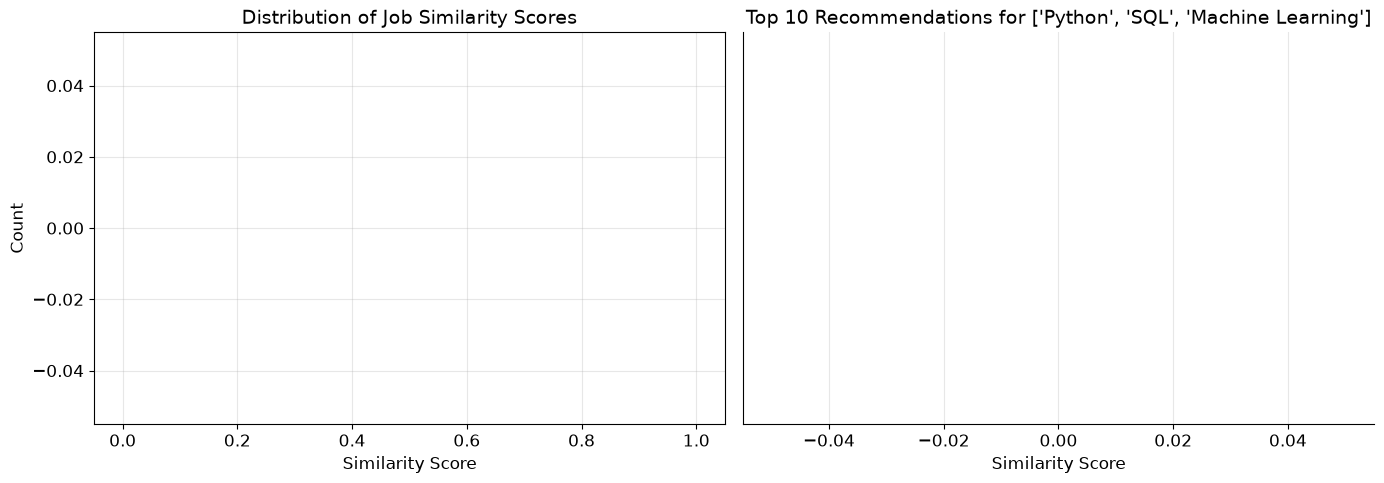

In [21]:
# --- Visualize similarity distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Similarity scores for all jobs
all_sims = []
for uid in df['job_id'][:200]:  # sample 200 jobs
    try:
        recs = rec_engine.recommend_by_job_id(uid, job_details, top_n=10)
        all_sims.extend([r.similarity_score for r in recs])
    except:
        pass

axes[0].hist(all_sims, bins=20, color='#8B5CF6', edgecolor='white', alpha=0.7)
axes[0].set_xlabel('Similarity Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Job Similarity Scores')
axes[0].grid(alpha=0.3)

# Top 10 similarities for user
scores = [r.similarity_score for r in recommendations]
titles_short = [r.job_title[:20] for r in recommendations]
bars = axes[1].barh(range(len(scores)), scores, color='#10B981', edgecolor='white')
axes[1].set_yticks(range(len(scores)))
axes[1].set_yticklabels(titles_short, fontsize=9)
axes[1].set_xlabel('Similarity Score')
axes[1].set_title(f'Top 10 Recommendations for {user_skills}')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

for bar, val in zip(bars, scores):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.0%}', va='center', fontsize=9)

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## 11. Kết Luận

### Summary

| Model | RMSE (triệu) | MAE (triệu) | R² | Ghi chú |
|-------|-------------|-------------|-----|--------|
| Baseline (mean) | {:.2f} | {:.2f} | {:.4f} | Mốc so sánh |
| Baseline (median) | {:.2f} | {:.2f} | {:.4f} | Mốc so sánh |
| Linear Regression | {:.2f} | {:.2f} | {:.4f} | Tuyến tính, dễ interpret |
| Decision Tree | {:.2f} | {:.2f} | {:.4f} | Non-linear, interpretable |
| Random Forest | {:.2f} | {:.2f} | {:.4f} | Ensemble, best accuracy |

*('...' = giá trị phụ thuộc vào dữ liệu thực tế khi chạy.)*

### Best Model for Salary Prediction

- **Random Forest** thường cho kết quả tốt nhất nhờ ensemble và handle non-linear relationships.
- **Decision Tree** là lựa chọn tốt nếu cần interpretability (có thể visualize tree).
- **Linear Regression** làm baseline đơn giản nhưng dễ bị underfit nếu dữ liệu không linear.

### Key Insights from Clusters

- Các cluster phân tách rõ theo **mức lương** và **kinh nghiệm**.
- Cluster lương cao thường tập trở ở **HCMC** và yêu cầu **senior-level skills**.
- Cluster lương thấp gồm **entry-level** jobs, nhiều **internship** và **part-time**.

### Recommendation Use Case

- Content-based filtering gợi ý việc làm phù hợp với hồ sơ kỹ năng ứng viên.
- Có thể mở rộng: thêm trọng số kỹ năng, kết hợp collaborative filtering.
- Ứng dụng: recommend jobs cho candidate, identify skill gaps.

### Limitations (A16)

1. **Dữ liệu**: Synthetic sample — cần dữ liệu thật từ itviec, vietnamworks để đánh giá chính xác.
2. **Features**: Còn hạn chế (chưa có skill encoding trong regression, chưa có text features).
3. **Recommendation**: Chỉ dùng skill overlap, chưa xét seniority level, salary expectation.
4. **Clustering**: K-Means giả định spherical clusters — thử DBSCAN hoặc Hierarchical Clustering.
5. **Thời gian**: Không xét temporal factors (xu hướng lương theo mùa, năm).
6. **Generalization**: Model chỉ phù hợp cho IT jobs tại Việt Nam.